In [1]:
import os
import pickle
import collections
import random
from typing import Tuple

import numpy as np
import gymnasium as gym
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm


In [2]:
class SAC_Actor(torch.nn.Module):
    def __init__(self,obs_dim:int,action_dim:int,hidden_size:int=64) -> None:
        super(SAC_Actor,self).__init__()
        self.fc1 = torch.nn.Linear(obs_dim,hidden_size)
        self.fc2 = torch.nn.Linear(hidden_size,action_dim)
        self.fc3 = torch.nn.Linear(hidden_size,action_dim)
            
    def forward(self,x:torch.Tensor) -> torch.Tensor:
        LOG_STD_MAX = 2
        LOG_STD_MIN = -20
        x = self.fc1(x)
        x = F.relu(x)
        mu = self.fc2(x)
        log_std = torch.tanh(self.fc3(x))
        log_std = torch.clamp(log_std, LOG_STD_MIN, LOG_STD_MAX)  # From SpinUp / Denis Yarats
        std = torch.exp(log_std)
        dist = torch.distributions.Normal(mu, std)
        sample = dist.sample()
        action = torch.tanh(sample)
        
        return action.detach().numpy()
    
class DDPG_Actor(torch.nn.Module):
    def __init__(self,obs_dim:int,action_dim:int,hidden_size:int=64) -> None:
        super(DDPG_Actor,self).__init__()
        self.fc1 = torch.nn.Linear(obs_dim,hidden_size)
        self.fc2 = torch.nn.Linear(hidden_size,action_dim)
            
    def forward(self,x:torch.Tensor) -> torch.tensor:
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = torch.tanh(x)
        
        return x.detach().numpy()
    
class PPO_Actor(torch.nn.Module):
    def __init__(self,obs_dim:int,action_dim:int,hidden_size:int=64) -> None:
        super(PPO_Actor, self).__init__()
        self.fc1 = torch.nn.Linear(obs_dim,hidden_size)
        self.fc2 = torch.nn.Linear(hidden_size,action_dim)
                    
    def forward(self,x:torch.Tensor) -> torch.tensor:
        x = F.relu(self.fc1(x))
        dist = self.fc2(x)
        dist = F.softmax(dist, dim = 0)
        action_probs = torch.distributions.Categorical(dist)
        picked_action = action_probs.sample()
                       
        return picked_action.item()

In [3]:
class Buffer():
    def __init__(self,capacity:int) -> None:
        self.buffer = collections.deque(maxlen=capacity)
        self.capacity = capacity
        
    def append(self,exp_data:tuple) -> None:
        self.buffer.append(exp_data)
        
    def fetch_all(self) -> Tuple:
        return self.buffer
            
    def __len__(self) -> int:
        return len(self.buffer)
    
    def save_to_disk(self, filename:str) -> None:
        os.makedirs(os.path.dirname(filename), exist_ok=True)
        with open(filename, 'wb') as f:
            pickle.dump(self.buffer, f)

In [4]:
class NormalizedActions(gym.ActionWrapper):
    '''
    Add this wrapper to normalize the action space. So the algorithm code can be general.
    '''
    def __init__(self, env):
        super().__init__(env)
    
    def action(self, action: np.ndarray) -> np.ndarray:
        # Force in range and clip
        low_bound = self.action_space.low
        upper_bound = self.action_space.high
        scale = (upper_bound - low_bound) * 0.5
        bias = (upper_bound + low_bound) * 0.5
        action = scale * action + bias
        action = np.clip(action, low_bound, upper_bound)
        return action

In [5]:
def eval_policy(env: gym.Env, 
         actor: torch.nn.Module,
         eval_episodes: int = 1000,
         seed: int = 0
         ) -> list:
     _ = env.reset(seed=seed)
     
     returns = []
     saved_obs = []
     saved_actions = []
     saved_rewards = []
     saved_next_states = []
     saved_dones = []
     
     with tqdm(total=eval_episodes, desc='Evaluation', unit='episodes') as pbar:
          for _ in range(eval_episodes):
               done = False
               obs,_ = env.reset()
               episode_return = 0
               episode_obs = []
               episode_actions = []
               episode_rewards = []
               episode_next_states = []
               episode_dones = []
               
               episode_obs.append(obs)
               while not done:
                    obs = torch.tensor(obs, dtype=torch.float32)
                    action = actor(obs)
                    next_state, reward, terminated, truncated, _ = env.step(action)
                    done = terminated or truncated
                    episode_actions.append(action)
                    episode_rewards.append(reward)
                    episode_next_states.append(next_state)
                    episode_dones.append(done)
                    episode_return += reward
                    obs = next_state
                    episode_obs.append(obs)
                    
               returns.append(episode_return)
               saved_obs.append(episode_obs)
               saved_actions.append(episode_actions)
               saved_rewards.append(episode_rewards)
               saved_next_states.append(episode_next_states)
               saved_dones.append(episode_dones)
               pbar.update(1)
            
     return returns, saved_obs, saved_actions, saved_rewards, saved_next_states, saved_dones

In [6]:
env = NormalizedActions(gym.make('Pendulum-v1'))

seed = 0
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
torch.backends.cudnn.deterministic = True

obs_dim = gym.spaces.utils.flatdim(env.observation_space)
action_dim = gym.spaces.utils.flatdim(env.action_space)
sac_actor = SAC_Actor(obs_dim,action_dim,hidden_size=64)
sac_actor.load_state_dict(torch.load('../Models/Pendulum_SAC500_Actor.pth'))

rewards_sac, saved_obs_sac, saved_actions_sac, saved_rewards_sac,\
    saved_next_obs_sac, saved_dones_sac = eval_policy(env,sac_actor,eval_episodes=1000,seed=seed)
ddpg_actor = DDPG_Actor(obs_dim,action_dim,hidden_size=64)
ddpg_actor.load_state_dict(torch.load('../Models/Pendulum_DDPG500_Actor.pth'))
rewards_ddpg, saved_obs_ddpg, saved_actions_ddpg, saved_rewards_ddpg,\
    saved_next_obs_ddpg, saved_dones_ddpg = eval_policy(env,ddpg_actor,eval_episodes=1000,seed=seed)


Evaluation: 100%|██████████| 1000/1000 [00:30<00:00, 32.30episodes/s]


In [7]:
env = gym.make('CartPole-v0')
obs_dim = gym.spaces.utils.flatdim(env.observation_space)
action_dim = gym.spaces.utils.flatdim(env.action_space)
ppo_actor = PPO_Actor(obs_dim,action_dim)
ppo_actor.load_state_dict(torch.load('../Models/CartPole_PPO100_Actor.pth'))
rewards_ppo1, saved_obs_ppo1, saved_actions_ppo1, saved_rewards_ppo1,\
    saved_next_obs_ppo1, saved_dones_ppo1 = eval_policy(env,ppo_actor,eval_episodes=300,seed=seed)
ppo_actor.load_state_dict(torch.load('../Models/CartPole_PPO180_Actor.pth'))
rewards_ppo2, saved_obs_ppo2, saved_actions_ppo2, saved_rewards_ppo2,\
    saved_next_obs_ppo2, saved_dones_ppo2 = eval_policy(env,ppo_actor,eval_episodes=300,seed=seed)
ppo_actor.load_state_dict(torch.load('../Models/CartPole_PPO1000_Actor.pth'))
rewards_ppo3, saved_obs_ppo3, saved_actions_ppo3, saved_rewards_ppo3,\
    saved_next_obs_ppo3, saved_dones_ppo3 = eval_policy(env,ppo_actor,eval_episodes=300,seed=seed)

/home/zhura/miniconda3/envs/torch/lib/python3.8/site-packages/gymnasium/envs/registration.py:513: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(
Evaluation: 100%|██████████| 300/300 [00:13<00:00, 22.05episodes/s]


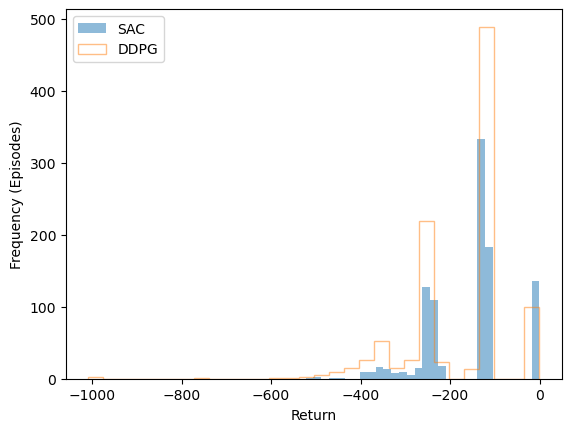

In [8]:
rewards_sac = np.array(rewards_sac)
rewards_ddpg = np.array(rewards_ddpg)

bin_num = 30

plt.hist(rewards_sac, bins=bin_num, alpha=0.5, label='SAC')
plt.hist(rewards_ddpg, bins=bin_num, alpha=0.5, label='DDPG',histtype='step')
plt.xlabel('Return')
plt.ylabel('Frequency (Episodes)')
plt.legend()
plt.show()

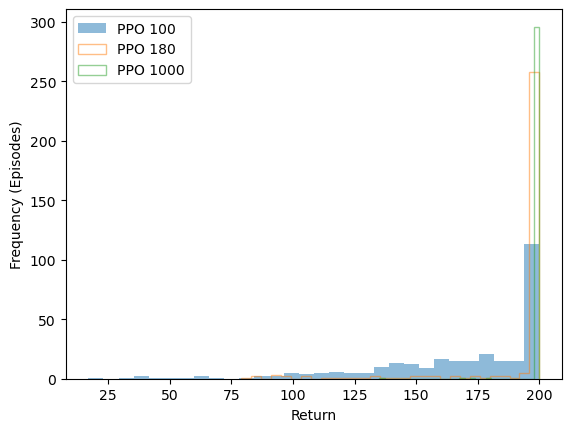

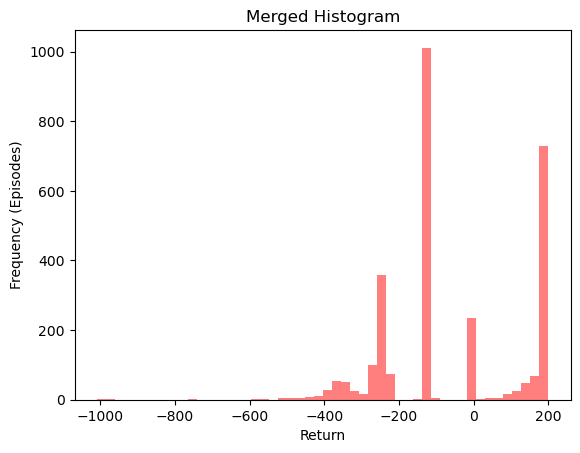

In [9]:
rewards_ppo1 = np.array(rewards_ppo1)
rewards_ppo2 = np.array(rewards_ppo2)
rewards_ppo3 = np.array(rewards_ppo3)

bin_num = 30
plt.hist(rewards_ppo1, bins=bin_num, alpha=0.5, label='PPO 100')
plt.hist(rewards_ppo2, bins=bin_num, alpha=0.5, label='PPO 180',histtype='step')
plt.hist(rewards_ppo3, bins=bin_num, alpha=0.5, label='PPO 1000',histtype='step')
plt.xlabel('Return')
plt.ylabel('Frequency (Episodes)')
plt.legend()
plt.show()

rewards_ppo_merged = np.concatenate((rewards_sac,rewards_ddpg,rewards_ppo1,rewards_ppo2,rewards_ppo3))
saved_obs_ppo = saved_obs_ppo1 + saved_obs_ppo2 + saved_obs_ppo3
saved_actions_ppo = saved_actions_ppo1 + saved_actions_ppo2 + saved_actions_ppo3
saved_rewards_ppo = saved_rewards_ppo1 + saved_rewards_ppo2 + saved_rewards_ppo3
saved_next_obs_ppo = saved_next_obs_ppo1 + saved_next_obs_ppo2 + saved_next_obs_ppo3
saved_dones_ppo = saved_dones_ppo1 + saved_dones_ppo2 + saved_dones_ppo3

bin_num = 50
plt.hist(rewards_ppo_merged, bins=bin_num, alpha=0.5,color='r')
plt.xlabel('Return')
plt.ylabel('Frequency (Episodes)')
plt.title('Merged Histogram')
plt.show()

In [10]:
def sample_rewards_indices(rewards, good_ratio, average_ratio, bad_ratio, total_samples, good_percentile=80, bad_percentile=20):
    good_threshold = np.percentile(rewards, good_percentile)
    bad_threshold = np.percentile(rewards, bad_percentile)
    good_indices = np.where(rewards >= good_threshold)[0]
    bad_indices = np.where(rewards <= bad_threshold)[0]
    average_indices = np.where((rewards > bad_threshold) & (rewards < good_threshold))[0]

    total_good = min(int(total_samples * good_ratio), len(good_indices))
    total_average = min(int(total_samples * average_ratio), len(average_indices))
    total_bad = min(int(total_samples * bad_ratio), len(bad_indices))
    
    replace_good = total_good > len(good_indices)
    replace_average = total_average > len(average_indices)
    replace_bad = total_bad > len(bad_indices)
    
    sampled_good_indices = np.random.choice(good_indices, total_good, replace=replace_good).tolist()
    sampled_average_indices = np.random.choice(average_indices, total_average, replace=replace_average).tolist()
    sampled_bad_indices = np.random.choice(bad_indices, total_bad, replace=replace_bad).tolist()
    
    return sampled_good_indices, sampled_average_indices, sampled_bad_indices

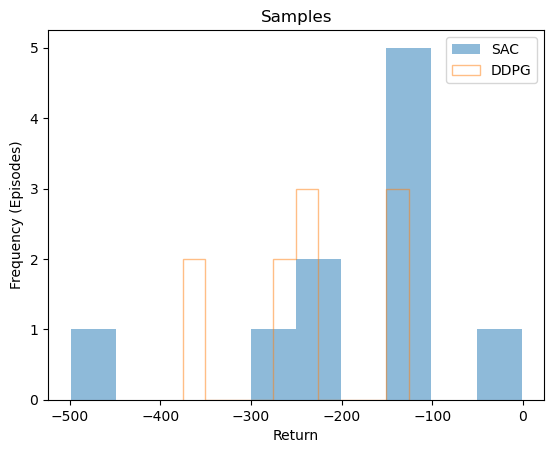

In [11]:
good_indices_sac, average_indices_sac, bad_indices_sac = sample_rewards_indices(rewards_sac,  0.1, 0.6, 0.3, 10,70,20)
good_indices_ddpg, average_indices_ddpg, bad_indices_ddpg = sample_rewards_indices(rewards_ddpg, 0.1, 0.6, 0.3, 10,70,20)

sample_indices_sac = good_indices_sac + average_indices_sac + bad_indices_sac
sample_indices_ddpg = good_indices_ddpg + average_indices_ddpg + bad_indices_ddpg 

plt.hist(rewards_sac[sample_indices_sac], bins=10, alpha=0.5, label='SAC')
plt.hist(rewards_ddpg[sample_indices_ddpg], bins=10, alpha=0.5, label='DDPG',histtype='step')
plt.xlabel('Return')
plt.ylabel('Frequency (Episodes)')
plt.legend()
plt.title('Samples')
plt.show()

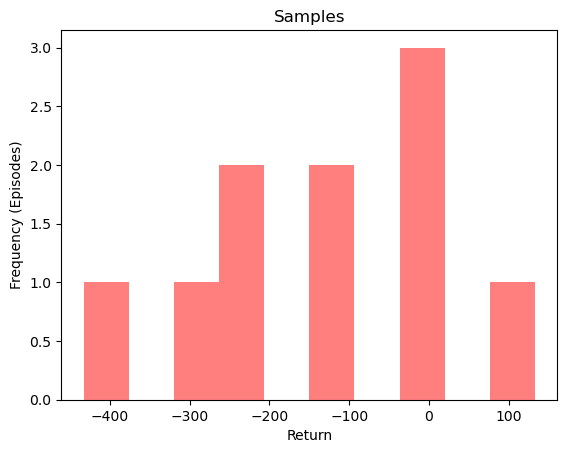

In [12]:
good_indices_ppo, average_indices_ppo, bad_indices_ppo = sample_rewards_indices(rewards_ppo_merged, 0.1, 0.6, 0.3, 10,70,20)
sample_indices_ppo = good_indices_ppo + average_indices_ppo + bad_indices_ppo
plt.hist(rewards_ppo_merged[sample_indices_ppo], bins=10, alpha=0.5, label='PPO',color='r')
plt.xlabel('Return')
plt.ylabel('Frequency (Episodes)')
plt.title('Samples')
plt.show()

In [15]:
def save_as_buffer(saved_obs, saved_actions, saved_rewards, saved_next_states, saved_dones, buffer_capacity, filename):
    buffer = Buffer(buffer_capacity)
    for i in range(len(saved_obs)):
        for j in range(len(saved_obs[i])-1):
            buffer.append((saved_obs[i][j], saved_actions[i][j], saved_rewards[i][j], saved_next_states[i][j], saved_dones[i][j]))
    buffer.save_to_disk(filename)

In [16]:
buffer_sac = save_as_buffer(saved_obs_sac,
                            saved_actions_sac,
                            saved_rewards_sac,
                            saved_next_obs_sac,
                            saved_dones_sac,
                            10000,
                            '../Data/Pendulum_SAC_OfflineBuffer_163.pkl')
    
buffer_ddpg = save_as_buffer(saved_obs_ddpg,
                            saved_actions_ddpg,
                            saved_rewards_ddpg,
                            saved_next_obs_ddpg,
                            saved_dones_ddpg,
                            10000,
                            '../Data/Pendulum_DDPG_OfflineBuffer_163.pkl')

buffer_ppo = save_as_buffer(saved_obs_ppo,
                            saved_actions_ppo,
                            saved_rewards_ppo,
                            saved_next_obs_ppo,
                            saved_dones_ppo,
                            10000,
                            '../Data/CartPole_PPO_OfflineBuffer_163.pkl')       